Extracting train-images.idx3-ubyte...
Extracting train-labels.idx1-ubyte...
Extracting t10k-images.idx3-ubyte...
Extracting t10k-labels.idx1-ubyte...

Training data shape: (60000, 784)
Testing data shape: (10000, 784)
Data successfully loaded!


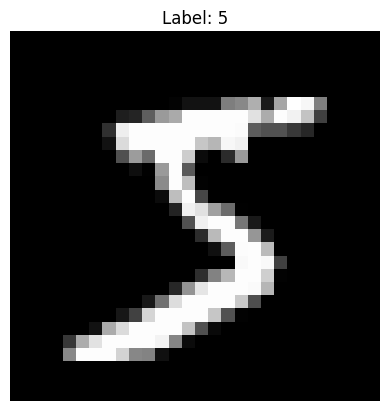

In [14]:
# Importing necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 

# Reading the UNCOMPRESSED pixel data
def extract_images_uncompressed(filename):
    print(f"Extracting {filename}...")
    with open(filename, 'rb') as f: 
        f.read(16) # Skipping magic number and dimensions header
        buf = f.read()
        data = np.frombuffer(buf, dtype=np.uint8)
        # Reshape into a flat array of 784 pixels per image (28x28)
        data = data.reshape(-1, 784)
        return data

# Reading the UNCOMPRESSED labels
def extract_labels_uncompressed(filename):
    print(f"Extracting {filename}...")
    with open(filename, 'rb') as f: 
        f.read(8) # Skipping magic number and count header
        buf = f.read()
        labels = np.frombuffer(buf, dtype=np.uint8)
        return labels

# Loading the datasets
X_train = extract_images_uncompressed('train-images.idx3-ubyte')
y_train = extract_labels_uncompressed('train-labels.idx1-ubyte')
X_test = extract_images_uncompressed('t10k-images.idx3-ubyte')
y_test = extract_labels_uncompressed('t10k-labels.idx1-ubyte')

# Verifying the shape of the data
print(f"\nTraining data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")
print("Data successfully loaded!")

# Visualizing a single digit to ensure it worked correctly
sample_digit = X_train[0].reshape(28, 28)
sample_label = y_train[0]

plt.imshow(sample_digit, cmap='gray')
plt.title(f"Label: {sample_label}")
plt.axis('off')
plt.show()

In [15]:
# DATA PREPROCESSING
print("Starting data normalization...")

# Normalizing the pixel values to be between 0 and 1
X_train_scaled = X_train / 255.0
X_test_scaled = X_test / 255.0

print("Data successfully scaled!")

# Checking the minimum and maximum values
print(f"Original min value: {X_train.min()}, Original max value: {X_train.max()}")
print(f"Scaled min value: {X_train_scaled.min()}, Scaled max value: {X_train_scaled.max()}")

Starting data normalization...
Data successfully scaled!
Original min value: 0, Original max value: 255
Scaled min value: 0.0, Scaled max value: 1.0


In [16]:
# MODEL TRAINING
from sklearn.ensemble import RandomForestClassifier
import time

print("Initializing the Random Forest model...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

print("Training the model... This usually takes 1 to 3 minutes. Please wait...")
start_time = time.time()


rf_model.fit(X_train_scaled, y_train)

end_time = time.time()
print(f"Model successfully trained in {round(end_time - start_time, 2)} seconds!")

Initializing the Random Forest model...
Training the model... This usually takes 1 to 3 minutes. Please wait...
Model successfully trained in 11.74 seconds!


Making predictions on the training data...
Making predictions on the testing data...

OVERALL F1-SCORES
Training F1-Score: 1.0000
Testing F1-Score:  0.9702

TABULAR RESULTS (TESTING DATA)
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.96      0.97      0.97      1032
           3       0.96      0.96      0.96      1010
           4       0.97      0.97      0.97       982
           5       0.98      0.96      0.97       892
           6       0.98      0.98      0.98       958
           7       0.97      0.96      0.97      1028
           8       0.96      0.95      0.96       974
           9       0.96      0.95      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000

Generating Confusion Matrix visualization...


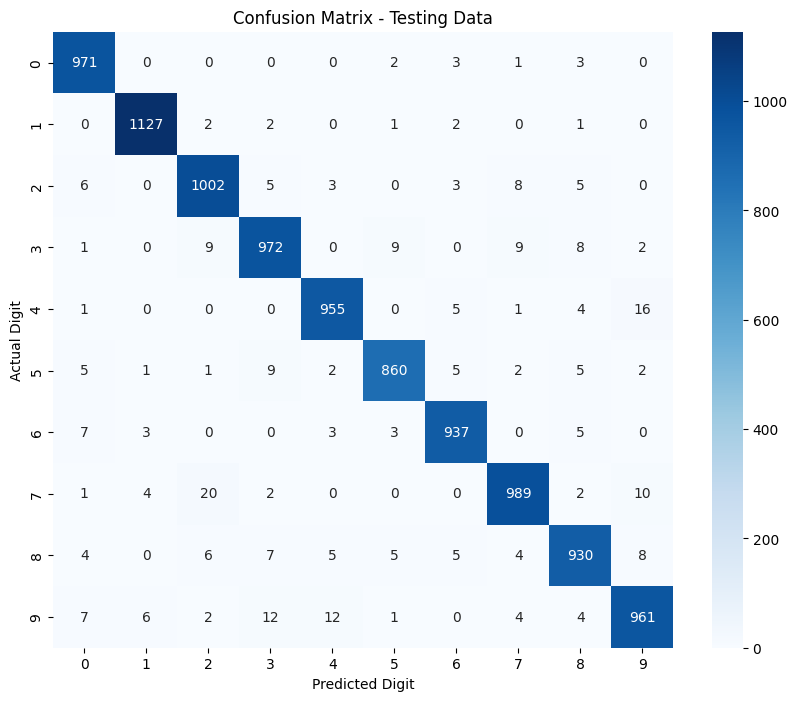

In [17]:
# MODEL EVALUATION & VISUALIZATIONS
from sklearn.metrics import classification_report, f1_score, confusion_matrix
import seaborn as sns

print("Making predictions on the training data...")
y_train_pred = rf_model.predict(X_train_scaled)

print("Making predictions on the testing data...")
y_test_pred = rf_model.predict(X_test_scaled)

# Calculating overall F1-Scores
f1_train = f1_score(y_train, y_train_pred, average='macro')
f1_test = f1_score(y_test, y_test_pred, average='macro')

print("\nOVERALL F1-SCORES")
print(f"Training F1-Score: {f1_train:.4f}")
print(f"Testing F1-Score:  {f1_test:.4f}")

# Generating the tabular classification report
print("\nTABULAR RESULTS (TESTING DATA)")
print(classification_report(y_test, y_test_pred))

# Generating the graphical confusion matrix
print("Generating Confusion Matrix visualization...")
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Testing Data')
plt.ylabel('Actual Digit')
plt.xlabel('Predicted Digit')
plt.show()